# Exploratory Data Analysis (EDA) - Flickr8k Test Set

Before passing our dataset through any pre-trained models (GIT, BLIP, BLIP-2) or evaluation metrics, we must thoroughly understand its structure. This notebook performs an Exploratory Data Analysis (EDA) on the raw 1,000-image test split of the Flickr8k dataset. 

By analyzing the image dimensions, caption lengths, and raw vocabulary, we can identify anomalies (like missing values or attached punctuation) and make informed decisions for our `data_cleaner.py` and `run_inference.py` pipelines.

### 1. Environment Setup & Data Loading
First, we will import the necessary libraries and load the raw JSON metadata file generated by our `data_loader.py` script.

In [1]:
import os
import json
import random
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter


data_dir = "../data/flickr8k_sample"
raw_file_path = os.path.join(data_dir, "raw_annotations.json")
images_dir = os.path.join(data_dir, "images")


with open(raw_file_path, 'r') as f:
    raw_data = json.load(f)

print("Libraries imported and data loaded successfully!")

Libraries imported and data loaded successfully!


### 2. Dataset Health & Integrity Check
In standard image captioning datasets, every image should ideally be paired with exactly 5 human-annotated reference captions. This step verifies that our dataset downloaded correctly without any missing, null, or corrupted text values.

In [3]:
total_images = len(raw_data)
missing_captions = 0
invalid_caption_counts = 0

for item in raw_data:
    captions = item.get("raw_captions", [])
    if len(captions) != 5:
        invalid_caption_counts += 1
    for cap in captions:
        if cap is None or str(cap).strip() == "":
            missing_captions += 1

print(f"Total Images: {total_images}")
print(f"Images with missing/incorrect number of captions: {invalid_caption_counts}")
print(f"Total empty/null caption strings: {missing_captions}")

Total Images: 1000
Images with missing/incorrect number of captions: 0
Total empty/null caption strings: 0


### 3. Qualitative Visual Inspection
Here, we randomly sample 5 images from our dataset and display it alongside its 5 raw human captions. This provides an intuitive understanding of how detailed and subjective the ground truth descriptions are. 

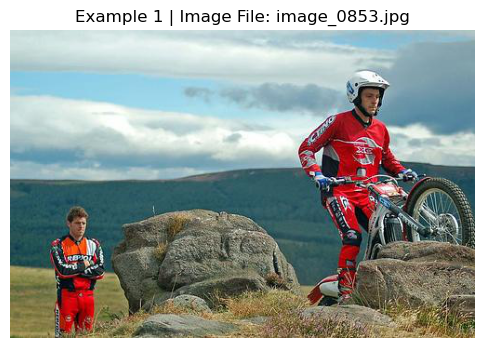

RAW HUMAN CAPTIONS:
  1. A dirt biker pushes his motorcycle up a rock while another rider watches .
  2. A man in red on a dirt bike struggles up a rock while another man in red watches .
  3. A man in red pushes his motocross bike up a rock .
  4. A man is looking on as another man attempts to climb a small boulder with his dirt bike .
  5. A red-clad man rides a bike through rocky ground while another man looks on




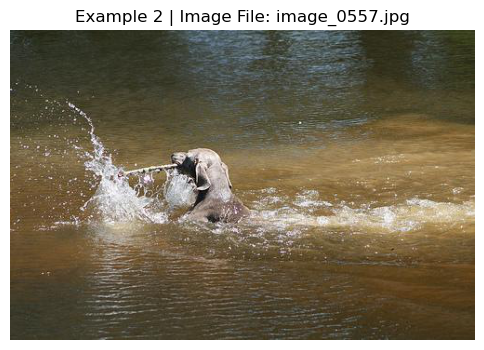

RAW HUMAN CAPTIONS:
  1. A dog is fetching a stick from a lake .
  2. A dog swimming with a stick in its mouth .
  3. a grey dog swimming through a river with a stick in his mouth
  4. Dog carries stick in mouth while in water .
  5. Dog swimming through water carrying stick in its mouth




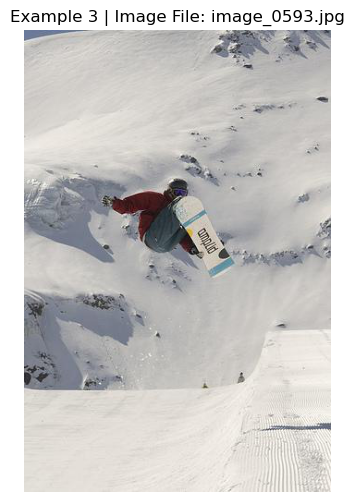

RAW HUMAN CAPTIONS:
  1. A man snowboards .
  2. A red-clothed snowboarder is performing an aerial trick .
  3. A snowboarder in the air over a snowy mountain .
  4. A snowboarder is in the air .
  5. A snowboarder is jumping in the air over a snow slope .




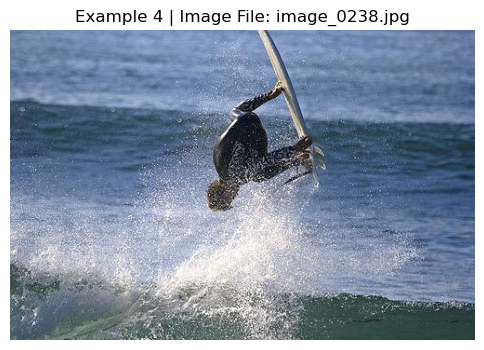

RAW HUMAN CAPTIONS:
  1. A surfer does a flip on a wave .
  2. A surfer is 90 degrees to the water
  3. A surfer is flipping up in the air on a surfboard .
  4. a surfer jumps out of the water .
  5. The surfer does a flip off of a wave .




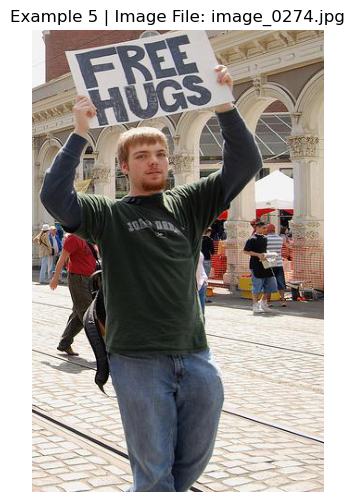

RAW HUMAN CAPTIONS:
  1. a man carrying a sign that says free hug along the sidewalk .
  2. A man holds up a " free hugs " sign above his head .
  3. A man is holding a sign that says " Free Hugs " .
  4. A young man in a black shirt is holding a Free Hugs sign .
  5. The man is wearing a green shirt and blue jeans and carrying a free hugs sign .




In [5]:
samples = random.sample(raw_data, 5)

for idx, sample in enumerate(samples):
    img_path = os.path.join(images_dir, sample["file_name"])

    img = Image.open(img_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Example {idx + 1} | Image File: {sample['file_name']}")
    plt.show()


    print("RAW HUMAN CAPTIONS:")
    for i, cap in enumerate(sample["raw_captions"]):
        print(f"  {i+1}. {cap}")
        
    print("\n" + "="*50 + "\n")

### 4. Image Dimensions Analysis
Vision-Language Models (VLMs) expect standardized input sizes. If our dataset contains images of wildly varying aspect ratios or extreme resolutions, we must ensure our inference script properly utilizes Hugging Face's `Processor` to resize and crop images without heavily distorting the subjects.

Analyzing image dimensions:


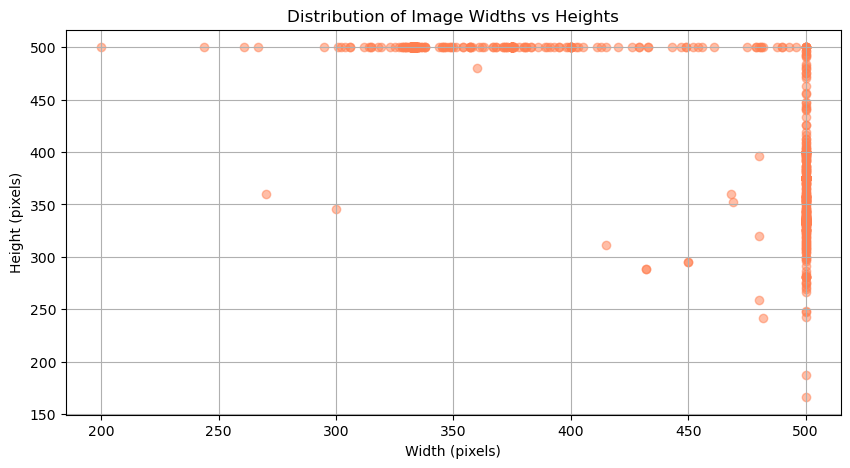

Average Width: 456 px
Average Height: 398 px


In [12]:
widths = []
heights = []

print("Analyzing image dimensions:")
for item in raw_data:
    img_path = os.path.join(images_dir, item["file_name"])
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(10, 5))
plt.scatter(widths, heights, alpha=0.5, color='coral')
plt.title("Distribution of Image Widths vs Heights")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.grid(True)

plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, "image_dimensions.png"), bbox_inches='tight')

plt.show()

print(f"Average Width: {sum(widths)/len(widths):.0f} px")
print(f"Average Height: {sum(heights)/len(heights):.0f} px")

The scatter plot shows the images are rectangular, not perfect squares.
The Hugging Face `Processor` functions will automatically resize and center-crop the images for us before they go into the models.

### 5. Caption Length Distribution
When generating text using models like BLIP-2 or GIT, we must define a `max_length` parameter. If we set it too low, the model's output will be truncated. If we set it too high, it wastes computational resources. By plotting the distribution of human caption lengths, we can determine the optimal maximum generation length.

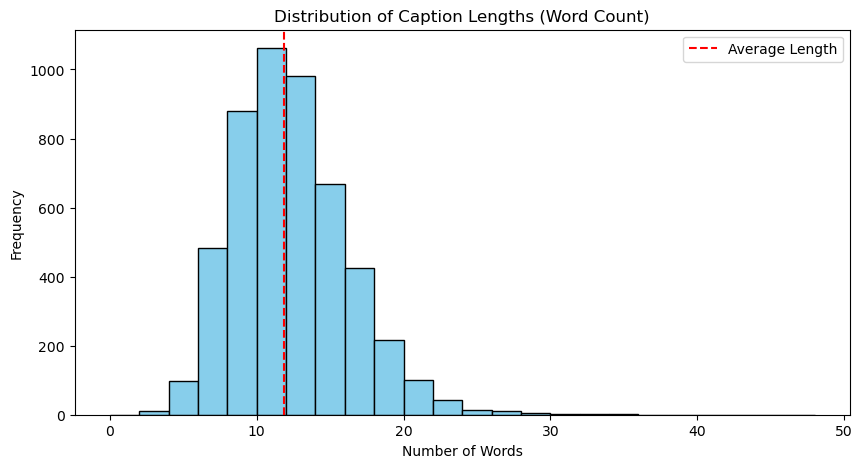

Shortest caption: 2 words
Longest caption: 34 words
Average caption: 11.8 words


In [13]:
all_captions = [cap for item in raw_data for cap in item["raw_captions"]]
caption_lengths = [len(cap.split()) for cap in all_captions]

plt.figure(figsize=(10, 5))
plt.hist(caption_lengths, bins=range(0, 50, 2), color='skyblue', edgecolor='black')
plt.title("Distribution of Caption Lengths (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.axvline(sum(caption_lengths)/len(caption_lengths), color='red', linestyle='--', label='Average Length')
plt.legend()

plt.savefig(os.path.join(plots_dir, "caption_lengths.png"), bbox_inches='tight')

plt.show()

print(f"Shortest caption: {min(caption_lengths)} words")
print(f"Longest caption: {max(caption_lengths)} words")
print(f"Average caption: {sum(caption_lengths)/len(caption_lengths):.1f} words")

The average caption is ~12 words long, and the absolute maximum is 34 words. 
During inference, we will set the `max_new_tokens` (or `max_length`) parameter for our models to **40**. This ensures no sentences are cut off, while preventing the models from wasting computation time generating unnecessarily long sequences.

### 6. Vocabulary and Punctuation Analysis
Evaluation metrics like CIDEr and BLEU are highly sensitive to exact string matches. If a human annotator wrote `"dog."` (with a period) but our model generates `"dog"`, the evaluator might penalize the model. This step identifies punctuation attached to tokens, justifying the need for a robust text-cleaning pipeline before evaluation.

In [10]:
#splitting all sentences into raw tokens (words) based purely on spaces
all_words = " ".join(all_captions).split()
word_counts = Counter(all_words)

print("Top 20 most frequent raw tokens:")
for word, count in word_counts.most_common(20):
    print(f"'{word}': {count}")

print("\n--- Example of why we need cleaning ---")

#Words that have periods attached to them
words_with_periods = [word for word in word_counts.keys() if word.endswith(".")]
print(f"Found {len(words_with_periods)} unique tokens ending with a period.")
print("Sample:", words_with_periods[:10])

Top 20 most frequent raw tokens:
'a': 5016
'.': 4509
'A': 2807
'in': 2315
'the': 1968
'on': 1383
'is': 1183
'and': 1041
'with': 972
'dog': 930
'man': 874
'of': 810
'Two': 532
'white': 515
'boy': 492
'black': 466
'are': 456
'girl': 416
'The': 415
',': 414

--- Example of why we need cleaning ---
Found 1 unique tokens ending with a period.
Sample: ['.']


The raw captions contain mixed casing (e.g., "A" vs "a") and heavy punctuation (periods and commas are among the most frequent tokens).
Good thing is we have no words with period (".") attached to them.
Automated evaluation metrics like BLEU and CIDEr often rely on exact string matching. Punctuational or capitalization differences between the model's prediction and the ground truth will artificially lower our scores.
Our `data_cleaner.py` script must convert all text to lowercase and strip all punctuation before we run the evaluation metrics.